# Explore Neo-Assyrian Letter Corpus
Quick-start notebook for inspecting the ORACC English translations dataset.

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TRANSLATIONS_CSV = Path('../processed_data/neo_assyrian/letters_translations.csv')

df = pd.read_csv(TRANSLATIONS_CSV)
print(f'{len(df):,} letters | {df["project"].nunique()} projects')
df.head()

In [ ]:
# Letter counts per project
counts = df.groupby('project')['text_id'].count().sort_values(ascending=False)
counts.plot(kind='barh', figsize=(8, 4), title='Letters per SAA Volume')
plt.xlabel('Number of letters')
plt.tight_layout()
plt.savefig('../outputs/neo_assyrian/letters_per_project.png', dpi=150)
plt.show()

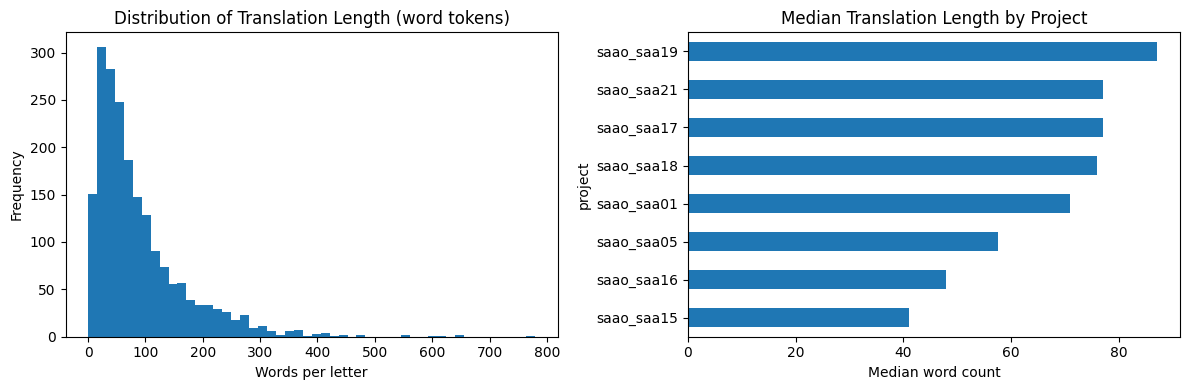

count    1993.0
mean       88.9
std        82.4
min         0.0
25%        34.0
50%        64.0
75%       116.0
max       780.0


In [8]:
# Translation length distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['token_count'].plot(
    kind='hist', bins=50, ax=axes[0],
    title='Distribution of Translation Length (word tokens)',
    xlabel='Words per letter'
)

df.groupby('project')['token_count'].median().sort_values().plot(
    kind='barh', ax=axes[1],
    title='Median Translation Length by Project',
    xlabel='Median word count'
)

plt.tight_layout()
plt.show()
print(df['token_count'].describe().round(1).to_string())

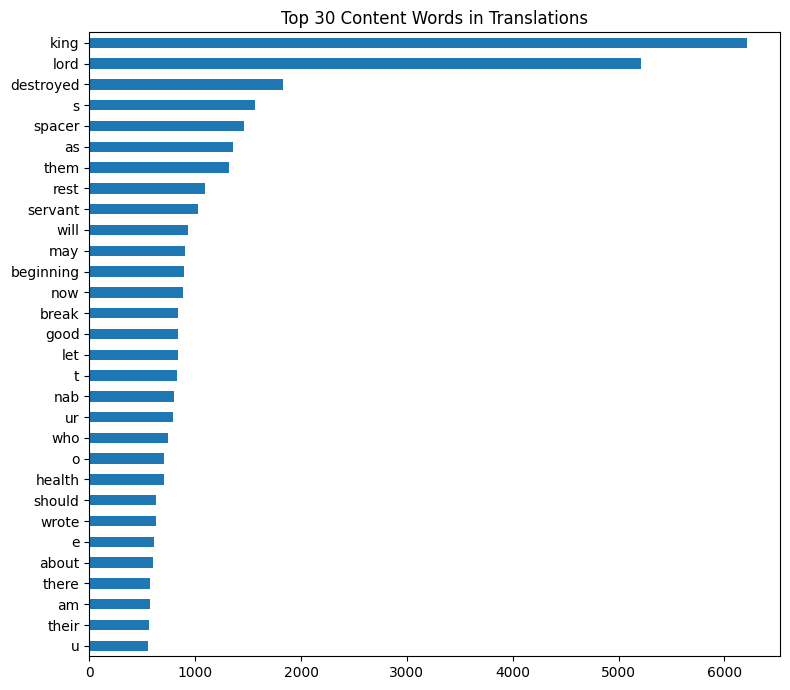

In [9]:
# Top 30 most frequent words across all translations
import re
from collections import Counter

STOPWORDS = {'the', 'a', 'an', 'of', 'to', 'and', 'in', 'is', 'it',
             'that', 'his', 'my', 'your', 'he', 'i', 'has', 'have',
             'not', 'are', 'was', 'with', 'for', 'me', 'be', 'this',
             'him', 'they', 'we', 'you', 'from', 'by', 'on', 'which'}

words = Counter()
for text in df['translation'].dropna():
    tokens = re.findall(r"[a-z]+", text.lower())
    words.update(t for t in tokens if t not in STOPWORDS)

top_words = pd.Series(dict(words.most_common(30)))
top_words.sort_values().plot(
    kind='barh', figsize=(8, 7), title='Top 30 Content Words in Translations'
)
plt.tight_layout()
plt.show()

In [10]:
# Inspect a single letter translation
sample_id = df['text_id'].iloc[0]
row = df[df['text_id'] == sample_id].iloc[0]
print(f"Text:    {row.text_id}")
print(f"Project: {row.project}")
print(f"Words:   {row.token_count}")
print()
print(row.translation)

Text:    P224395
Project: saao_saa01
Words:   119

To the king, my lord: Your servant Adda-hati. Good health to the king, my lord! (Ammili'ti) the son of Amiri readied himself with 300 she-camels, intending to attack the booty being [tran]sferred from Damascus to Assyria. [I heard of this and] sent word to Bel-i[qbi]; he came and we went together to meet the booty. He saw us, ambushed us from behind, and we had a fight. [1],500 [boot]y sheep from the city of Huzaza, [1],500 sheep [......] city of [......], [...]2 men [......] men [...... (Break) We returned and went in pursuit [after] him, getting as far as Il[...]ani, but could not catch up with him; (the terrain) was too difficult, [it was not fit] either for horses or for chariots [...... (Rest destroyed)


## Numerical Estimates in Translations

In [ ]:
ESTIMATES_CSV = Path('../processed_data/neo_assyrian/numerical_estimates.csv')

est = pd.read_csv(ESTIMATES_CSV)
print(f'{len(est):,} estimates across {est["text_id"].nunique():,} letters')
est.head(10)

In [ ]:
# Distribution of numeric values (Arabic numerals only, drop outliers for readability)
arabic = est['numeric_value'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Log-scale histogram of all values
axes[0].hist(arabic, bins=60, log=True, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Numeric Values (log scale)')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Count (log)')

# Most common numeric values
top_vals = arabic.value_counts().head(20).sort_index()
top_vals.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('20 Most Frequent Numeric Values')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Average number of estimates per letter, by project
est_per_letter = (
    est.groupby(['project', 'text_id'])
    .size()
    .reset_index(name='n_estimates')
    .groupby('project')['n_estimates']
    .mean()
    .sort_values()
)

est_per_letter.plot(kind='barh', figsize=(8, 4), color='steelblue',
                    title='Mean Numerical Estimates per Letter by Project')
plt.xlabel('Mean estimates per letter')
plt.tight_layout()
plt.show()

In [ ]:
# Letters with the most numerical estimates
top_letters = (
    est.groupby(['text_id', 'project'])
    .size()
    .reset_index(name='n_estimates')
    .sort_values('n_estimates', ascending=False)
    .head(10)
)
print("Top 10 letters by number of numerical estimates:")
print(top_letters.to_string(index=False))

# Preview the top letter
top_id = top_letters.iloc[0]['text_id']
print(f"\nEstimates found in {top_id}:")
print(est[est['text_id'] == top_id][['match_text', 'numeric_value', 'context']].to_string(index=False))